# Task 3 — scPRINT-2 zero-shot cross-species embedding

This notebook follows one reproducible path: the small-v2 checkpoint, the cell-type token, the KNN input graph, and the legacy paper-compatible evaluator. Each scientific step is visible; reusable implementation stays in `scprint2`.


## Protocol contract

- Dataset: cat and tiger Task 3 cells.
- Biological label: `cell_type_ontology_term_id`.
- Batch/organism key: `orig.ident`.
- Representation: scPRINT-2 cell-type token with the stored KNN-cell input.
- Evaluator: `scib==1.1.3`, `scanpy==1.9.1`.
- Aggregate: `0.4 × Batch correction + 0.6 × Bio conservation`.


In [1]:
import json
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scprint2.benchmark.task3 import (
    Task3Config,
    embed_task3,
    finetune_task3_checkpoint,
    load_task3_checkpoint,
    load_task3_dataset,
    prepare_task3_dataset,
    save_task3_embedding,
    seed_task3,
    summarize_task3_dataset,
    validate_task3_output_paths,
)
from scprint2.evaluation.task3_scib import (
    BATCH_METRICS,
    BIO_METRICS,
    Task3Scib113Config,
)

REPO_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists()
)
RUN_ROOT = REPO_ROOT / "data/results/cross_species_embedding/task3_fresh_ontology_knn_mmd003_20260815"
SCORES = RUN_ROOT / "task3_scib113_precomputed_scores.csv"
SCIB_METADATA = RUN_ROOT / "task3_scib113_precomputed_scores.metadata.json"
COMPLETE = RUN_ROOT / "task3_scib113_precomputed_scores.COMPLETE"
UMAP_ROOT = REPO_ROOT / "data/results/cross_species_embedding/task3_fresh_umaps_scoring_graph_20260818/plots"
UMAP_DATA = UMAP_ROOT / "task3_fresh_scored_embeddings_umaps.h5ad"
UMAP_METADATA = UMAP_ROOT / "task3_fresh_scored_embeddings_umaps.metadata.json"
RUN_EMBEDDING = False


No module named 'adasplash'
FlashAttention is not installed, not using it..


## Artifact registry

The notebook separates inputs, embeddings, score tables, metadata, completion markers, and visualization artifacts.


In [2]:
artifact_registry = pd.DataFrame(
    {
        "artifact": ["scores", "scIB metadata", "completion marker", "UMAP coordinates", "UMAP metadata"],
        "path": [SCORES, SCIB_METADATA, COMPLETE, UMAP_DATA, UMAP_METADATA],
    }
)
artifact_registry["exists"] = artifact_registry["path"].map(Path.exists)
display(artifact_registry)
assert artifact_registry["exists"].all()


,artifact,path,exists
0,scores,/Users/jkobject/Documents/scPRINT/data/results...,True
1,scIB metadata,/Users/jkobject/Documents/scPRINT/data/results...,True
2,completion marker,/Users/jkobject/Documents/scPRINT/data/results...,True
3,UMAP coordinates,/Users/jkobject/Documents/scPRINT/data/results...,True
4,UMAP metadata,/Users/jkobject/Documents/scPRINT/data/results...,True


## Data audit

The compact UMAP H5AD preserves the exact 27,200 scored cells and annotations. It is used for review only; it is not an alternative embedding input.


In [3]:
umap_data = ad.read_h5ad(UMAP_DATA)
audit_view = ad.AnnData(
    X=np.zeros((umap_data.n_obs, 0), dtype=np.float32),
    obs=umap_data.obs.rename(columns={"organism": "orig.ident"}).copy(),
)
audit_config = Task3Config(
    mode="scprint2-zero-shot",
    input="task_3_embed.h5ad",
    checkpoint="small-v2.ckpt",
    output="scprint2_zero_shot.h5ad",
    notebook_provenance="cross-species-embbedding.ipynb",
)
display(summarize_task3_dataset(audit_view, audit_config))


cells                                  27200
genes                                      0
labels                                    14
batches                                    2
unknown_labels                          2947
batch_key                         orig.ident
label_key         cell_type_ontology_term_id
Name: Task3 dataset audit, dtype: object

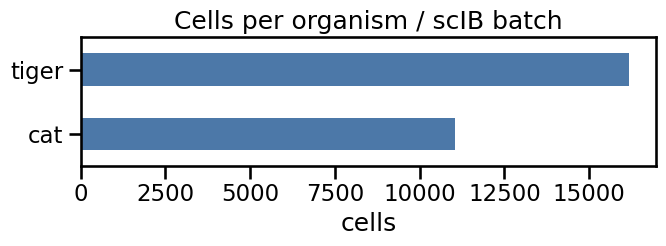

In [4]:
batch_counts = umap_data.obs["organism"].value_counts()
ax = batch_counts.sort_values().plot.barh(figsize=(7, 2.8), color="#4c78a8")
ax.set_title("Cells per organism / scIB batch")
ax.set_xlabel("cells")
ax.set_ylabel("")
plt.tight_layout()


,cells
converted_cell_type_ontology,
pulmonary alveolar type 2 cell,3453
ciliated cell,3345
mesenchymal cell,3278
Unknown,2947
epithelial cell,2933
pulmonary alveolar type 1 cell,2372
endothelial cell,1966
club cell,1468
pulmonary alveolar epithelial cell,1240


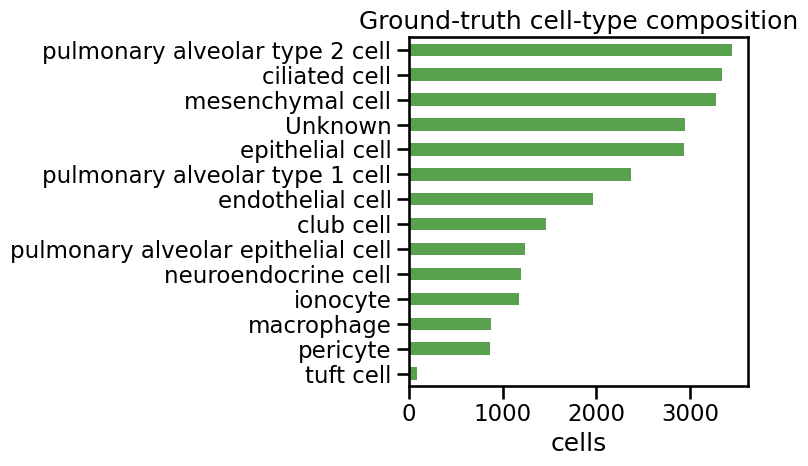

In [5]:
label_counts = umap_data.obs["converted_cell_type_ontology"].value_counts()
display(label_counts.rename("cells").to_frame())
ax = label_counts.sort_values().plot.barh(figsize=(8, 5), color="#59a14f")
ax.set_title("Ground-truth cell-type composition")
ax.set_xlabel("cells")
ax.set_ylabel("")
plt.tight_layout()


## Optional inference

The following cells expose one call at a time. They remain disabled in the checked-in notebook because checkpoint inference is expensive and the validated artifacts already exist.


In [6]:
input_h5ad = REPO_ROOT / "notebooks/scPRINT-2-repro-notebooks/data/task_3_embed.h5ad"
checkpoint = Path("/path/to/small-v2.ckpt")
fresh_output = RUN_ROOT / "notebook_scprint2_zero_shot_small_v2_knn.h5ad"
embedding_config = Task3Config(
    mode="scprint2-zero-shot",
    input=input_h5ad,
    checkpoint=checkpoint,
    output=fresh_output,
    notebook_provenance="Task3 scPRINT-2 zero-shot cell-token KNN notebook",
    batch_key="orig.ident",
    cell_type_key="cell_type_ontology_term_id",
    embed_how="random expr",
    embed_max_len=2800,
    use_knn=True,
    rebuild_knn_graph=True,
    seed=42,
)
display(pd.Series(embedding_config.as_dict(), name="embedding configuration"))


mode                                                              scprint2-zero-shot
input                              /Users/jkobject/Documents/scPRINT/notebooks/sc...
checkpoint                                                    /path/to/small-v2.ckpt
output                             /Users/jkobject/Documents/scPRINT/data/results...
notebook_provenance                Task3 scPRINT-2 zero-shot cell-token KNN notebook
batch_key                                                                 orig.ident
cell_type_key                                             cell_type_ontology_term_id
batch_size                                                                        32
num_workers                                                                        4
num_epochs                                                                         8
embed_how                                                                random expr
embed_max_len                                                    

In [7]:
if RUN_EMBEDDING:
    seed_task3(embedding_config.seed)
    reserved_paths = validate_task3_output_paths(embedding_config)
    display(pd.Series([str(path) for path in reserved_paths], name="reserved outputs"))


In [8]:
if RUN_EMBEDDING:
    task3_data = load_task3_dataset(embedding_config)
    display(summarize_task3_dataset(task3_data, embedding_config))


In [9]:
if RUN_EMBEDDING:
    task3_model = load_task3_checkpoint(embedding_config)
    print(type(task3_model).__name__)


In [10]:
if RUN_EMBEDDING:
    task3_data, knn_graph_rebuilt = prepare_task3_dataset(
        task3_data, task3_model, embedding_config
    )
    display(pd.Series({"KNN graph rebuilt": knn_graph_rebuilt}, name="preparation"))


In [11]:
if RUN_EMBEDDING:
    task3_embedding = embed_task3(task3_model, task3_data, embedding_config)
    display(pd.Series({key: list(value.shape) for key, value in task3_embedding.obsm.items()}, name="obsm"))


In [12]:
if RUN_EMBEDDING:
    embedding_artifacts = save_task3_embedding(
        task3_embedding,
        task3_data,
        embedding_config,
        knn_graph_rebuilt=knn_graph_rebuilt,
    )
    display(pd.Series(embedding_artifacts.as_dict(), name="saved artifacts"))


## Artifact validation

A result is accepted only when the score CSV, evaluator metadata, embedding metadata, completion marker, and UMAP provenance agree.


In [13]:
embedding_metadata_path = RUN_ROOT / "scprint2_zero_shot_small_v2_knn.metadata.json"
required = [SCORES, SCIB_METADATA, embedding_metadata_path, COMPLETE, UMAP_METADATA]
missing = [str(path) for path in required if not path.exists()]
assert not missing, f"Missing provenance artifacts: {missing}"
scib_metadata = json.loads(SCIB_METADATA.read_text())
embedding_metadata = json.loads(embedding_metadata_path.read_text())
umap_metadata = json.loads(UMAP_METADATA.read_text())
assert scib_metadata["versions"]["scib"] == "1.1.3"
assert scib_metadata["versions"]["scanpy"] == "1.9.1"
assert scib_metadata["total_formula"] == "0.4 * Batch correction + 0.6 * Bio conservation"
assert umap_metadata["methods"]["scprint2"]["embedding_shape"][0] == scib_metadata["cells"]
display(pd.Series({
    "cells": scib_metadata["cells"],
    "genes": embedding_metadata["genes"],
    "labels": scib_metadata["labels"],
    "batches": scib_metadata["batches"],
    "checkpoint": embedding_metadata["checkpoint_name"],
    "seed": embedding_metadata["seed"],
    "KNN graph rebuilt": embedding_metadata["settings"]["knn_graph_rebuilt"],
}, name="validated provenance"))


cells                        27200
genes                        57066
labels                          14
batches                          2
checkpoint           small-v2.ckpt
seed                            42
KNN graph rebuilt             True
Name: validated provenance, dtype: object

## Detailed scIB scores

The complete metric vector is shown before the three aggregate columns. Missing raw metrics remain missing.


In [14]:
scores = pd.read_csv(SCORES).set_index("Method")
aggregate_columns = ["Batch correction", "Bio conservation", "Total"]
display(scores[aggregate_columns].sort_values("Total", ascending=False))


,Batch correction,Bio conservation,Total
Method,,,
scPRINT-2-FT-cell-token-mmd003-knn,0.524544,0.763302,0.667799
scPRINT-2-ZS-all-tokens-except-assay-organism-pca50,0.419287,0.666912,0.567862
scPRINT-2-ZS-cell-token-knn,0.506897,0.602559,0.564294


,score
ASW_label/batch,0.860078
PCR_batch,0.686476
graph_conn,0.929900
kBET,0.043230
iLISI,0.014799
NMI_cluster/label,0.573383
ARI_cluster/label,0.488054
ASW_label,0.511764
cLISI,0.950114
hvg_overlap,NaN


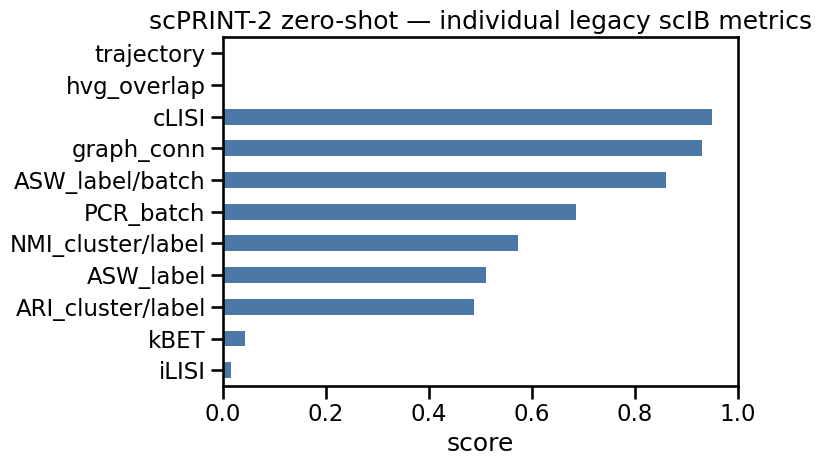

In [15]:
reported_method = "scPRINT-2-ZS-cell-token-knn"
detailed_metrics = scores.loc[reported_method, [*BATCH_METRICS, *BIO_METRICS]].rename("score")
display(detailed_metrics.to_frame())
ax = detailed_metrics.sort_values().plot.barh(figsize=(8, 5), color="#4c78a8", xlim=(0, 1))
ax.set_title("scPRINT-2 zero-shot — individual legacy scIB metrics")
ax.set_xlabel("score")
plt.tight_layout()


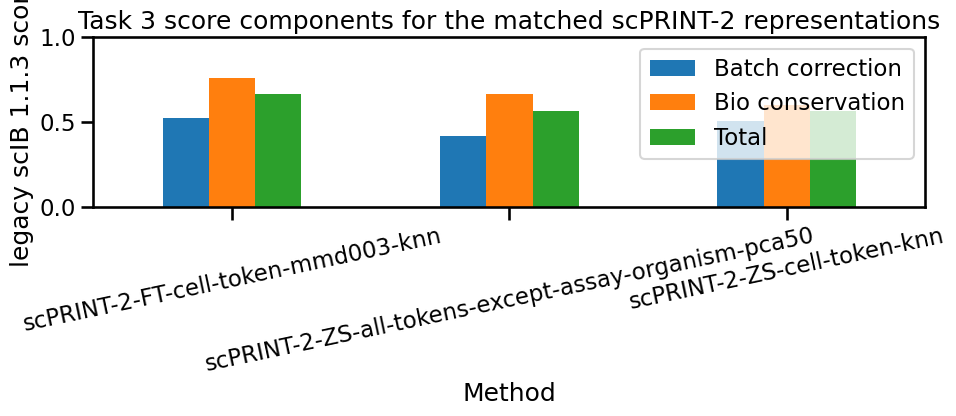

In [16]:
ax = scores[aggregate_columns].plot.bar(figsize=(10, 4.5), ylim=(0, 1), rot=12)
ax.set_title("Task 3 score components for the matched scPRINT-2 representations")
ax.set_ylabel("legacy scIB 1.1.3 score")
plt.tight_layout()


## UMAP diagnostics

These UMAPs come from the exact scored embeddings produced by the dedicated UMAP task. They are reused here, not recomputed.


![Task 3 scored embeddings overview](../../data/results/cross_species_embedding/task3_fresh_umaps_scoring_graph_20260818/plots/task3_fresh_scored_embeddings_umap_overview.png)


In [17]:
umap_files = pd.Series(
    {
        "organism": UMAP_ROOT / "scprint2__organism.png",
        "ground truth": UMAP_ROOT / "scprint2__converted_cell_type_ontology.png",
        "predicted cell type": UMAP_ROOT / "scprint2__converted_predicted_cell_type_ontology.png",
        "overview": UMAP_ROOT / "task3_fresh_scored_embeddings_umap_overview.png",
    },
    name="validated UMAP files",
)
display(umap_files.map(str).to_frame())
assert umap_files.map(Path.exists).all()


,validated UMAP files
organism,/Users/jkobject/Documents/scPRINT/data/results...
ground truth,/Users/jkobject/Documents/scPRINT/data/results...
predicted cell type,/Users/jkobject/Documents/scPRINT/data/results...
overview,/Users/jkobject/Documents/scPRINT/data/results...


### Zero-shot organism, truth, and prediction panels

![Organism](../../data/results/cross_species_embedding/task3_fresh_umaps_scoring_graph_20260818/plots/scprint2__organism.png)

![Ground truth](../../data/results/cross_species_embedding/task3_fresh_umaps_scoring_graph_20260818/plots/scprint2__converted_cell_type_ontology.png)

![Prediction](../../data/results/cross_species_embedding/task3_fresh_umaps_scoring_graph_20260818/plots/scprint2__converted_predicted_cell_type_ontology.png)


## Classification diagnostics

The projection below is descriptive. It checks where the zero-shot predicted ontology names concentrate relative to ground truth; it is not part of scIB.


scprint2_converted_predicted_cell_type_ontology,pulmonary alveolar type 2 cell,glomerular capillary endothelial cell,ileal goblet cell,chondrocyte,type EC enteroendocrine cell,Sertoli cell,pulmonary alveolar type 1 cell,basal cell of epidermis,MHC-II-positive classical monocyte,kidney proximal straight tubule epithelial cell,club cell,type G enteroendocrine cell
converted_cell_type_ontology,,,,,,,,,,,,
pulmonary alveolar type 2 cell,0.849,0.002,0.053,0.000,0.002,0.000,0.003,0.003,0.000,0.003,0.011,0.001
ciliated cell,0.161,0.246,0.069,0.112,0.020,0.197,0.007,0.019,0.000,0.057,0.006,0.025
mesenchymal cell,0.070,0.542,0.007,0.124,0.001,0.026,0.041,0.002,0.000,0.000,0.000,0.000
Unknown,0.135,0.181,0.050,0.154,0.018,0.081,0.013,0.157,0.020,0.003,0.004,0.005
epithelial cell,0.168,0.074,0.244,0.003,0.172,0.010,0.031,0.009,0.000,0.062,0.011,0.050
pulmonary alveolar type 1 cell,0.390,0.005,0.331,0.001,0.043,0.000,0.106,0.011,0.000,0.004,0.011,0.000
endothelial cell,0.061,0.807,0.003,0.010,0.013,0.008,0.070,0.005,0.002,0.004,0.001,0.001
club cell,0.548,0.016,0.212,0.017,0.028,0.007,0.050,0.016,0.000,0.002,0.021,0.003
pulmonary alveolar epithelial cell,0.364,0.064,0.083,0.006,0.159,0.009,0.030,0.003,0.005,0.002,0.146,0.017


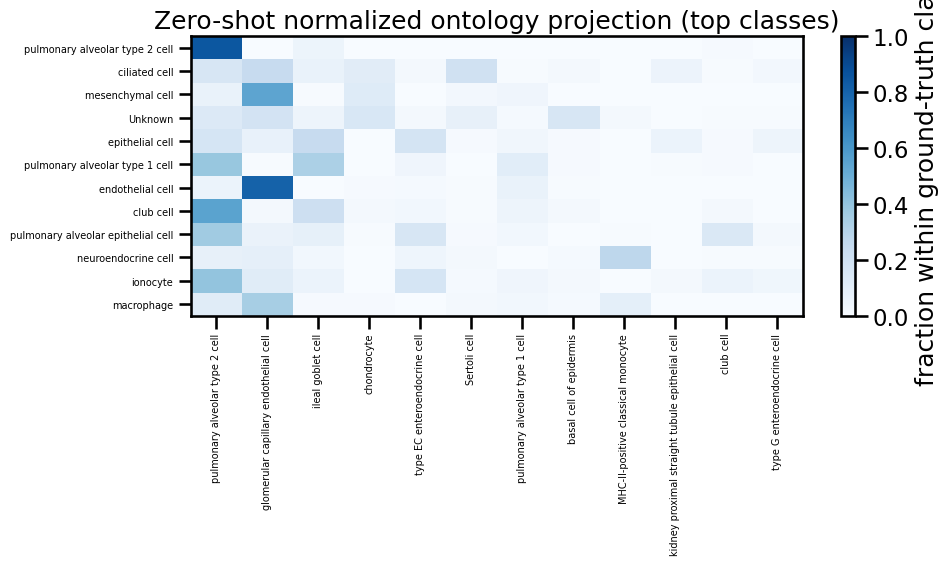

In [18]:
truth = umap_data.obs["converted_cell_type_ontology"].astype(str)
prediction = umap_data.obs["scprint2_converted_predicted_cell_type_ontology"].astype(str)
top_truth = truth.value_counts().head(12).index
top_prediction = prediction.value_counts().head(12).index
confusion = pd.crosstab(truth, prediction, normalize="index").reindex(
    index=top_truth, columns=top_prediction, fill_value=0
)
display(confusion.round(3))
fig, ax = plt.subplots(figsize=(10, 6))
image = ax.imshow(confusion, aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(confusion.columns)), confusion.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(confusion.index)), confusion.index, fontsize=7)
ax.set_title("Zero-shot normalized ontology projection (top classes)")
fig.colorbar(image, ax=ax, label="fraction within ground-truth class")
plt.tight_layout()


## Interpretation boundary

This notebook verifies one locked pipeline and makes its intermediate evidence visible. It does not isolate the causal contribution of KNN, token choice, checkpoint choice, or preprocessing; those require matched ablations.
